In [5]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from getdist import MCSamples, plots

In [6]:
# Load the data (updated for the warning)
df = pd.read_csv("../output/mf_w_lowz2.txt", sep=r"\s+", comment="#", header=None)

# Check the shape just to be sure
print(df.shape)  # should be (n_samples, at least 4): omega_m, sigma8, prior, post

# You’ll need to check how many columns you have
# Assuming the order is: omega_m, sigma8_input, prior, posterior
# df.columns = ["omega_m", "sigma8", "prior", "posterior"]
df.columns = ["w", "prior", "posterior"]

(3200, 3)


In [7]:
# --- Step 1: Prepare samples array ---
samples = df[["w"]].values

# --- Step 2: Parameter names and LaTeX labels ---
names = ['w']
labels = [r'w']

weights = np.exp(df["posterior"] - df["posterior"].max())
weights /= weights.sum()  # Normalize weights

# --- Step 3: Create MCSamples object ---
mc = MCSamples(samples=samples, names=names, labels=labels)

# Print the fitted value with 68% credible interval
#    mean ± 1σ:
print("mean ± σ:", mc.mean('w'), "±", mc.std('w'))

print("inline:", mc.getInlineLatex('w'))   # e.g. w = -1.0003 \pm 0.0009


Removed no burn in
mean ± σ: -0.9999681232070146 ± 0.0015400461737155708
inline: w = -0.99997\pm 0.0015


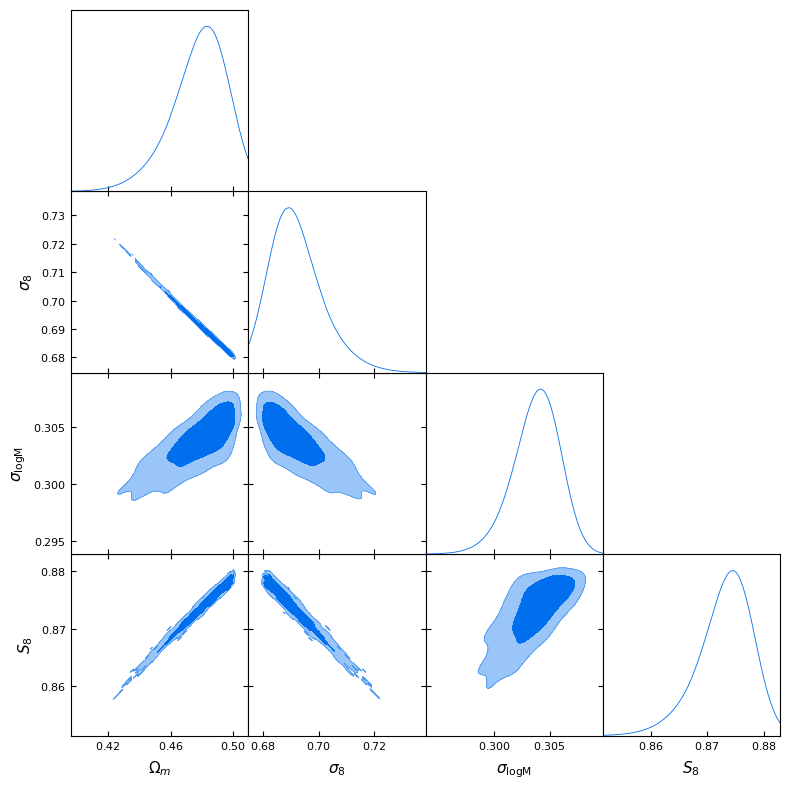

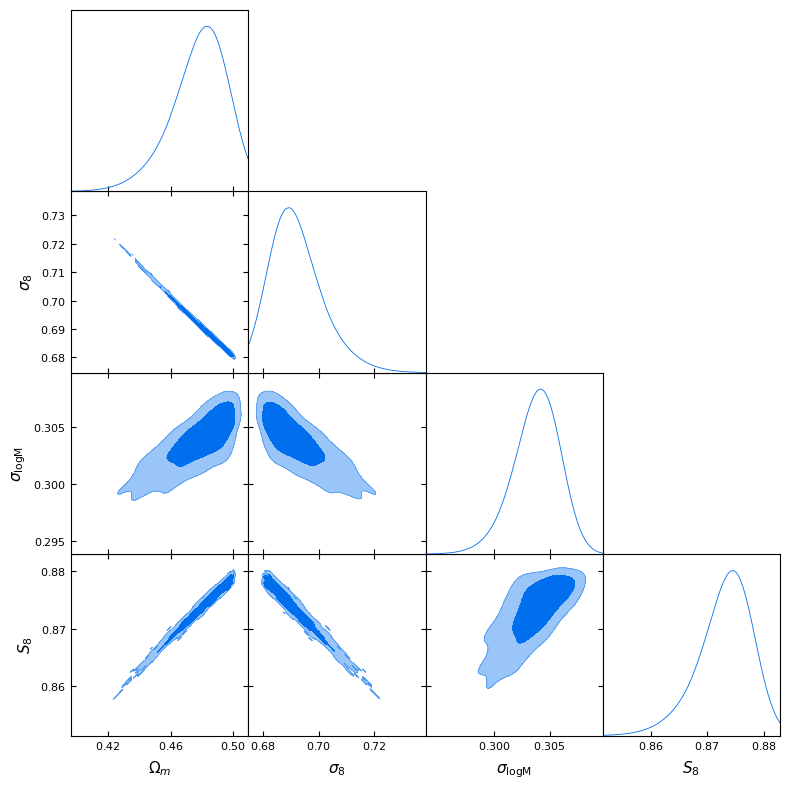

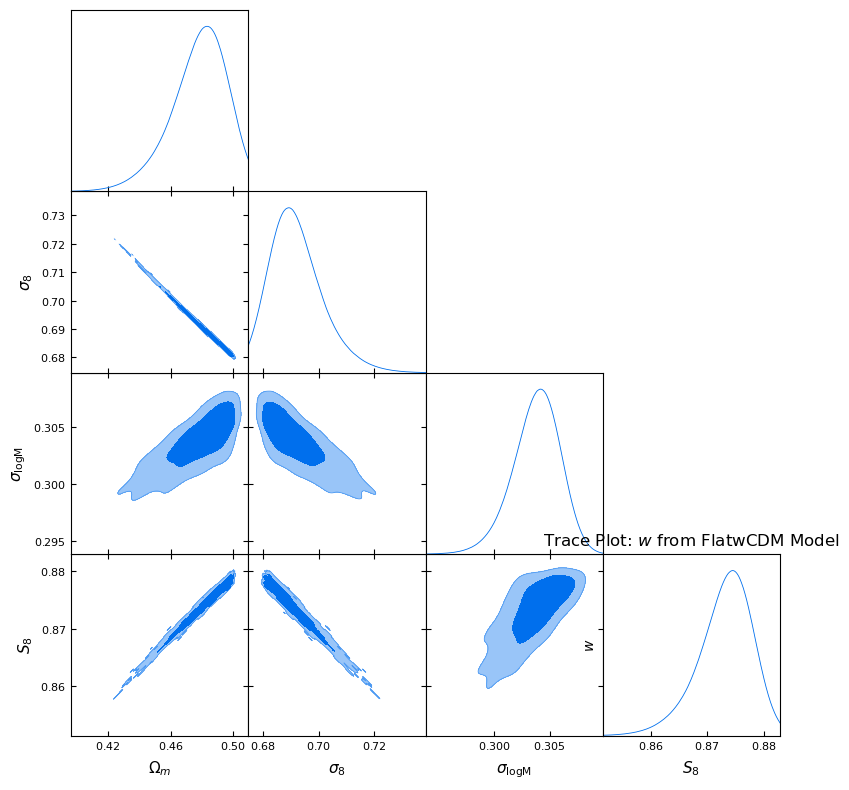

In [8]:
# Trace plot for omega_m
plt.plot(df["w"], color='steelblue')
w_mean = np.mean(df["w"])
plt.axhline(w_mean, color="red", linestyle="--", label=f"mean = {w_mean:.5f}")
plt.ylabel(r'$w$')
plt.title("Trace Plot: $w$ from FlatwCDM Model")

plt.show()

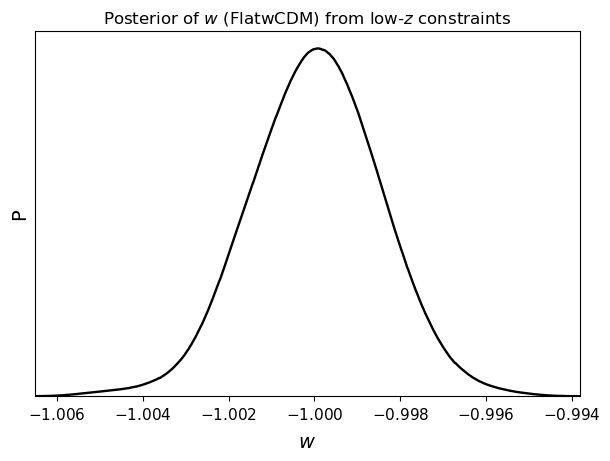

In [9]:
# posterior plot
g = plots.getSinglePlotter()
g.plot_1d(mc, "w", normalized=True)
plt.title(r"Posterior of $w$ (FlatwCDM) from low-$z$ constraints")
plt.show()

In [10]:
# Load the data (updated for the warning)
df1 = pd.read_csv("../output/mf_noise_base.txt", sep=r"\s+", comment="#", header=None)
df2 = pd.read_csv("../output/mf_noise_date_v2.txt", sep=r"\s+", comment="#", header=None)
df3 = pd.read_csv("../output/mf_noise_v1.txt", sep=r"\s+", comment="#", header=None)

# Check the shape just to be sure
print(df.shape)  # should be (n_samples, at least 4): omega_m, sigma8, prior, post

# You’ll need to check how many columns you have
# Assuming the order is: omega_m, sigma8_input, prior, posterior
df1.columns = ["omega_m", "sigma8", "prior", "posterior"]
df2.columns = ["omega_m", "sigma8", "prior", "posterior"]
df3.columns = ["omega_m", "sigma8", "prior", "posterior"]

(3200, 3)


In [11]:
# --- Apply burn-in: drop first 30% of each chain ---
burn_frac = 0.3

def burn_df(df, frac):
    n = len(df)
    n_burn = int(frac * n)
    return df.iloc[n_burn:].reset_index(drop=True)

df1 = burn_df(df1, burn_frac)
df2 = burn_df(df2, burn_frac)
df3 = burn_df(df3, burn_frac)

# (Optional) check shapes
print(df1.shape, df2.shape, df3.shape)

(44800, 4) (44800, 4) (44800, 4)


Removed no burn in


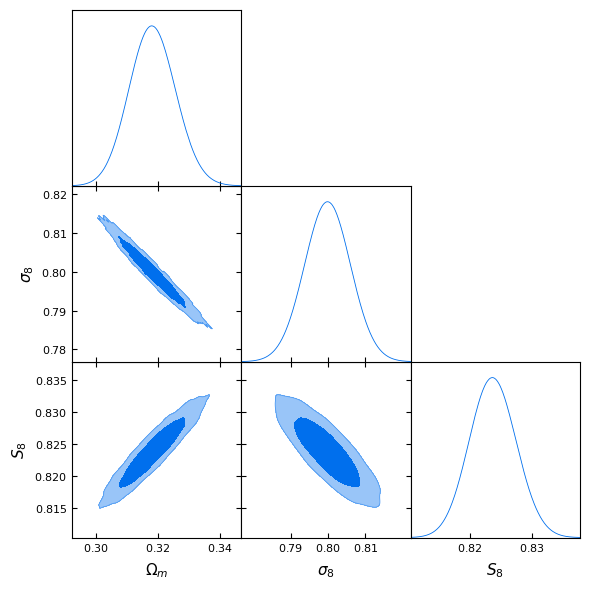

In [12]:
from getdist import MCSamples, plots

# --- Step 1: Compute S8 ---
df1["S8"] = df1["sigma8"] * (df1["omega_m"] / 0.3)**0.5

# --- Step 2: Prepare samples array ---
samples = df1[["omega_m", "sigma8", "S8"]].values

# --- Step 3: Parameter names and LaTeX labels ---
names = ['omega_m', 'sigma8', 'S8']
labels = [r'\Omega_m', r'\sigma_8', r'S_8']

# --- Step 4: Create MCSamples object ---
mc_samples = MCSamples(samples=samples, names=names, labels=labels)
# Smooth more → smoother contours
mc_samples.smooth_scale_1D = 0.9
mc_samples.smooth_scale_2D = 2.5   # increase this if still too jagged (try 2.0, 2.5)
# --- Step 5: Triangle plot ---
g = plots.getSubplotPlotter()
#g.settings.fine_bins_2D = 100  # or 150, 200 if needed
g.triangle_plot(mc_samples, filled=True)
plt.show()

Removed no burn in


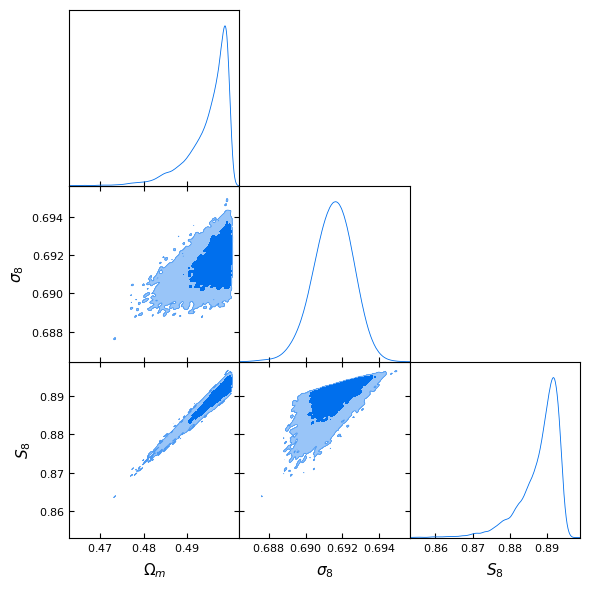

In [13]:
from getdist import MCSamples, plots

# --- Step 1: Compute S8 ---
df2["S8"] = df2["sigma8"] * (df2["omega_m"] / 0.3)**0.5

# --- Step 2: Prepare samples array ---
samples = df2[["omega_m", "sigma8", "S8"]].values

# --- Step 3: Parameter names and LaTeX labels ---
names = ['omega_m', 'sigma8', 'S8']
labels = [r'\Omega_m', r'\sigma_8', r'S_8']

# --- Step 4: Create MCSamples object ---
mc_samples = MCSamples(samples=samples, names=names, labels=labels)

# --- Step 5: Triangle plot ---
g = plots.getSubplotPlotter()
#g.settings.fine_bins_2D = 100  # or 150, 200 if needed
g.triangle_plot(mc_samples, filled=True)
plt.show()

(38080, 4)
Removed no burn in


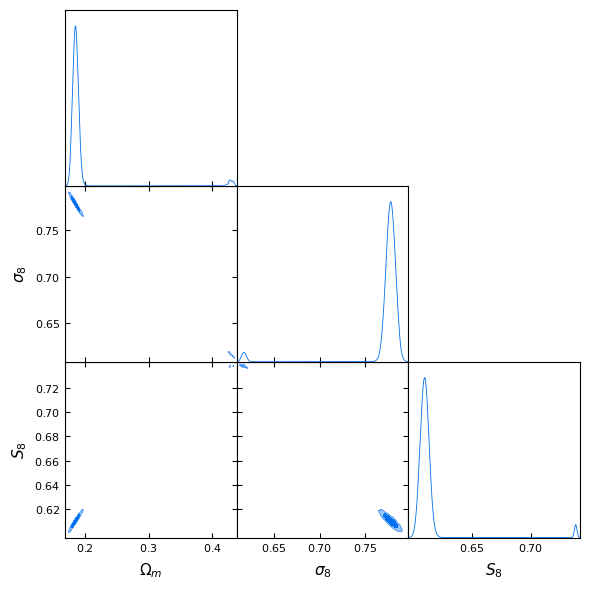

In [14]:
df = pd.read_csv("../output/mf_noise_data_v3.txt", sep=r"\s+", comment="#", header=None)
burn = int(len(df) * 0.3)
df = df.iloc[burn:].reset_index(drop=True)

# Check the shape just to be sure
print(df.shape)  # should be (n_samples, at least 4): omega_m, sigma8, prior, post

# You’ll need to check how many columns you have
# Assuming the order is: omega_m, sigma8_input, prior, posterior
df.columns = ["omega_m", "sigma8", "prior", "posterior"]

# --- Step 1: Compute S8 ---
df["S8"] = df["sigma8"] * (df["omega_m"] / 0.3)**0.5

# --- Step 2: Prepare samples array ---
samples = df[["omega_m", "sigma8", "S8"]].values

# --- Step 3: Parameter names and LaTeX labels ---
names = ['omega_m', 'sigma8', 'S8']
labels = [r'\Omega_m', r'\sigma_8', r'S_8']

# --- Step 4: Create MCSamples object ---
mc_samples = MCSamples(samples=samples, names=names, labels=labels)

# --- Step 5: Triangle plot ---
g = plots.getSubplotPlotter()
#g.settings.fine_bins_2D = 100  # or 150, 200 if needed
g.triangle_plot(mc_samples, filled=True)
plt.show()

(44800, 4)
Removed no burn in


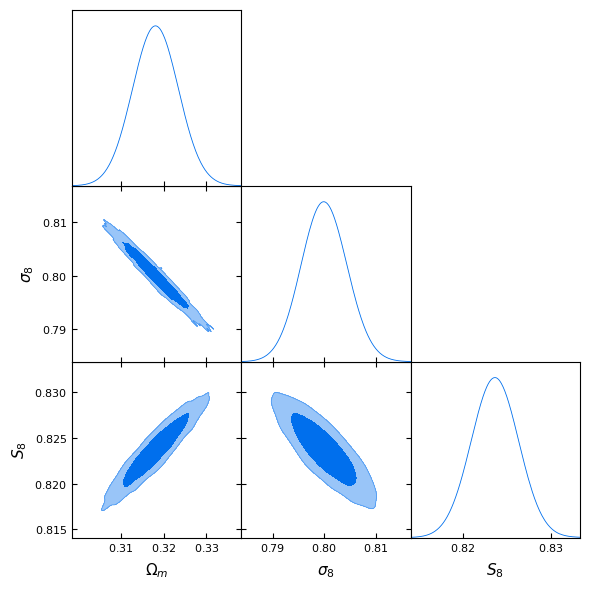

In [15]:
df = pd.read_csv("../output/mf_noise_v2.txt", sep=r"\s+", comment="#", header=None)
burn = int(len(df) * 0.3)
df = df.iloc[burn:].reset_index(drop=True)
# Check the shape just to be sure
print(df.shape)  # should be (n_samples, at least 4): omega_m, sigma8, prior, post

# You’ll need to check how many columns you have
# Assuming the order is: omega_m, sigma8_input, prior, posterior
df.columns = ["omega_m", "sigma8", "prior", "posterior"]

# --- Step 1: Compute S8 ---
df["S8"] = df["sigma8"] * (df["omega_m"] / 0.3)**0.5

# --- Step 2: Prepare samples array ---
samples = df[["omega_m", "sigma8", "S8"]].values

# --- Step 3: Parameter names and LaTeX labels ---
names = ['omega_m', 'sigma8', 'S8']
labels = [r'\Omega_m', r'\sigma_8', r'S_8']

# --- Step 4: Create MCSamples object ---
mc_samples = MCSamples(samples=samples, names=names, labels=labels)
# Smooth more → smoother contours
mc_samples.smooth_scale_1D = 0.9
mc_samples.smooth_scale_2D = 2.5   # increase this if still too jagged (try 2.0, 2.5)

# --- Step 5: Triangle plot ---
g = plots.getSubplotPlotter()
#g.settings.fine_bins_2D = 100  # or 150, 200 if needed
g.triangle_plot(mc_samples, filled=True)
plt.show()

(29120, 5)
Removed no burn in


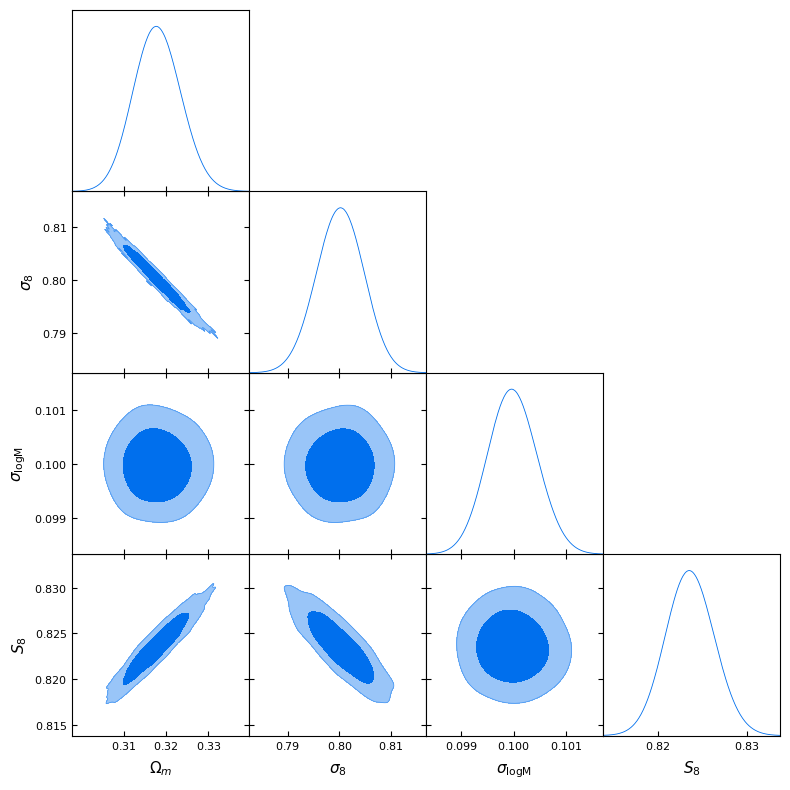

In [16]:
df = pd.read_csv("../output/mf_noise_fit_v2.txt", sep=r"\s+", comment="#", header=None)

df.columns = ["omega_m", "sigma8", "sigma_logm", "prior", "posterior"]

# --- Burn 30% ---
burn = int(len(df) * 0.3)
df = df.iloc[burn:].reset_index(drop=True)

# Check the shape just to be sure
print(df.shape)  # should be (n_samples, at least 4): omega_m, sigma8, prior, post

# You’ll need to check how many columns you have
# Assuming the order is: omega_m, sigma8_input, prior, posterior
# --- Step 1: Compute S8 ---
df["S8"] = df["sigma8"] * (df["omega_m"] / 0.3)**0.5

# --- Step 2: Prepare samples array ---
samples = df[["omega_m", "sigma8", "sigma_logm", "S8"]].values

# --- Step 3: Parameter names and LaTeX labels ---
names = ['omega_m', 'sigma8', 'sigma_logm', 'S8']
labels = [r'\Omega_m', r'\sigma_8', r'\sigma_{\rm{logM}}', r'S_8']

# --- Step 4: Create MCSamples object ---
mc_samples = MCSamples(
    samples=samples,
    names=names,
    labels=labels
)

# Smooth more → smoother contours
mc_samples.smooth_scale_1D = 0.9
mc_samples.smooth_scale_2D = 2.5   # increase this if still too jagged (try 2.0, 2.5)
# --- Step 5: Triangle plot ---
g = plots.getSubplotPlotter()
#g.settings.fine_bins_2D = 100  # or 150, 200 if needed
g.triangle_plot(mc_samples, filled=True)
plt.show()

Removed no burn in
Removed no burn in
Removed no burn in


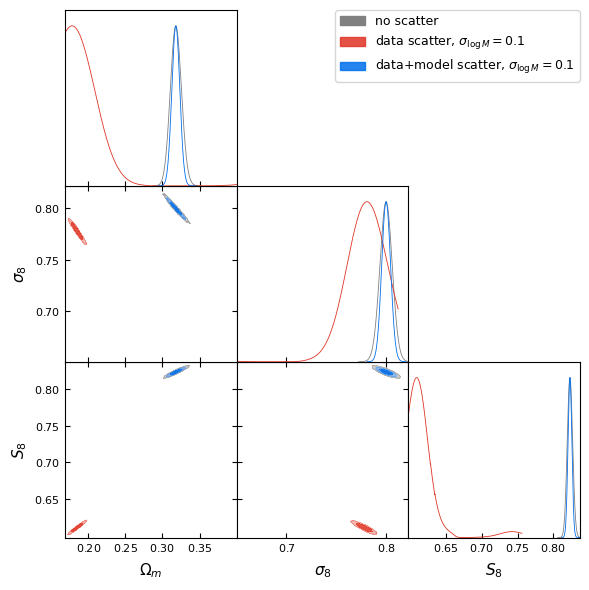

In [17]:
import pandas as pd
from getdist import MCSamples, plots
import matplotlib.pyplot as plt

def make_chain(path):
    df = pd.read_csv(path, sep=r"\s+", comment="#", header=None)
    df.columns = ["omega_m", "sigma8", "prior", "posterior"]

    # burn 30%
    burn = int(len(df) * 0.3)
    df = df.iloc[burn:].reset_index(drop=True)

    # S8
    df["S8"] = df["sigma8"] * (df["omega_m"] / 0.3)**0.5

    samples = df[["omega_m", "sigma8", "S8"]].values

    names  = ['omega_m', 'sigma8', 'S8']
    labels = [r'\Omega_m', r'\sigma_8', r'S_8']

    ranges = {'omega_m': (0.1, 0.4), 'sigma8':  (0.65, 1.0)}

    mc = MCSamples(samples=samples, names=names, labels=labels, ranges=ranges, ignore_rows=0)
    mc.smooth_scale_1D = 0.9
    mc.smooth_scale_2D = 2.5
    return mc

# paths for your three cases
file_no_scatter      = "../output/mf_noise_base.txt"
file_data_scatter    = "../output/mf_noise_data_v3.txt"
file_both_scatter    = "../output/mf_noise_v2.txt"

mc_no    = make_chain(file_no_scatter)
mc_data  = make_chain(file_data_scatter)
mc_both  = make_chain(file_both_scatter)

# colours for BOTH 1D and 2D
#mc_no.settings.color   = "#1f77b4"
#mc_data.settings.color = "#ff7f0e"
#mc_both.settings.color = "#2ca02c"

chains = [mc_no, mc_data, mc_both]

g = plots.getSubplotPlotter()

g.triangle_plot(
    chains,
    filled=True,
    #colors=["#1f77b4", "#ff7f0e", "#2ca02c"],   # blue, orange, green
    legend_labels=[
        "no scatter",
        r"data scatter, $\sigma_{\log M}=0.1$",
        r"data+model scatter, $\sigma_{\log M}=0.1$",
    ],
)

plt.show()


(44800, 4)
Removed no burn in


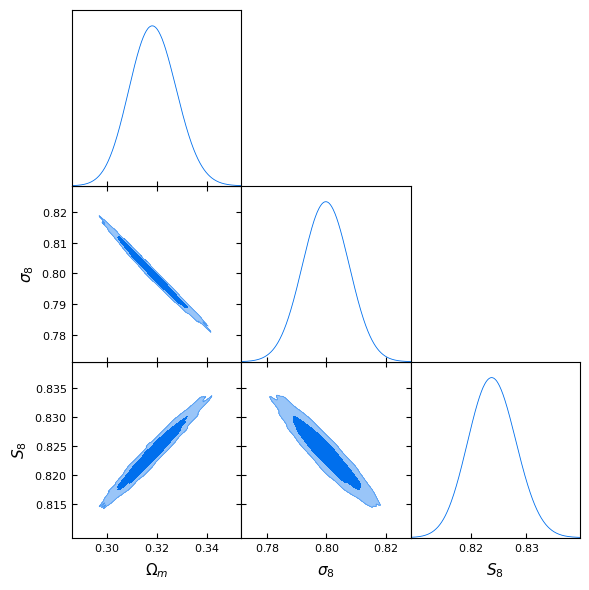

In [19]:
df = pd.read_csv("../output/mf_noise_massde_v1.txt", sep=r"\s+", comment="#", header=None)
burn = int(len(df) * 0.3)
df = df.iloc[burn:].reset_index(drop=True)
# Check the shape just to be sure
print(df.shape)  # should be (n_samples, at least 4): omega_m, sigma8, prior, post

# You’ll need to check how many columns you have
# Assuming the order is: omega_m, sigma8_input, prior, posterior
df.columns = ["omega_m", "sigma8", "prior", "posterior"]

# --- Step 1: Compute S8 ---
df["S8"] = df["sigma8"] * (df["omega_m"] / 0.3)**0.5

# --- Step 2: Prepare samples array ---
samples = df[["omega_m", "sigma8", "S8"]].values

# --- Step 3: Parameter names and LaTeX labels ---
names = ['omega_m', 'sigma8', 'S8']
labels = [r'\Omega_m', r'\sigma_8', r'S_8']

# --- Step 4: Create MCSamples object ---
mc_samples = MCSamples(samples=samples, names=names, labels=labels)
# Smooth more → smoother contours
mc_samples.smooth_scale_1D = 0.9
mc_samples.smooth_scale_2D = 2.5   # increase this if still too jagged (try 2.0, 2.5)

# --- Step 5: Triangle plot ---
g = plots.getSubplotPlotter()
#g.settings.fine_bins_2D = 100  # or 150, 200 if needed
g.triangle_plot(mc_samples, filled=True)
plt.show()

(56000, 5)
Removed no burn in


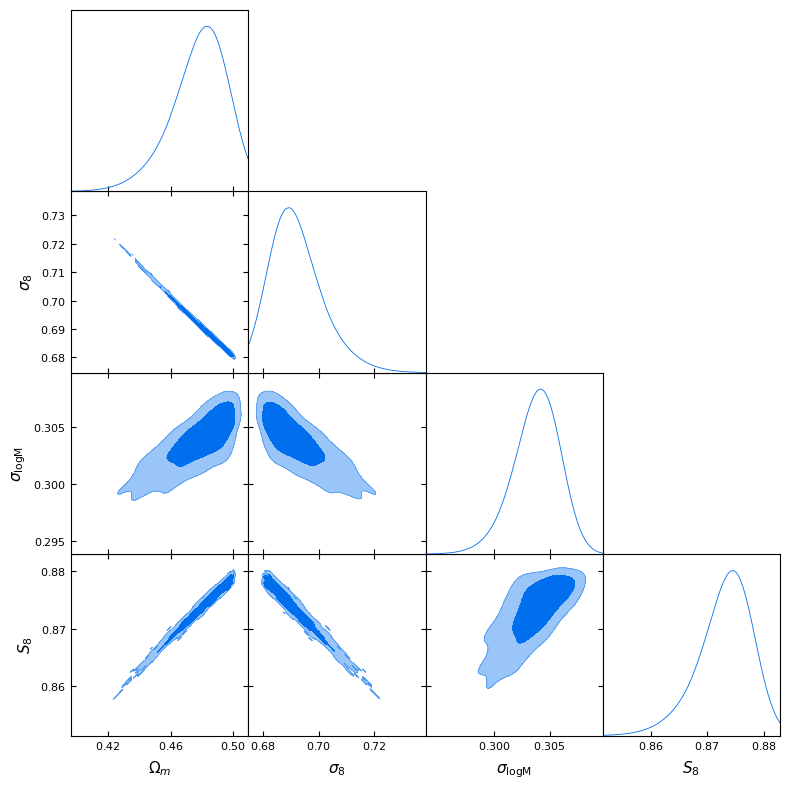

In [18]:
df = pd.read_csv("../output/scatter_massde_fit_v1.txt", sep=r"\s+", comment="#", header=None)

df.columns = ["omega_m", "sigma8", "sigma_logm", "prior", "posterior"]

# --- Burn 30% ---
burn = int(len(df) * 0.3)
df = df.iloc[burn:].reset_index(drop=True)

# Check the shape just to be sure
print(df.shape)  # should be (n_samples, at least 4): omega_m, sigma8, prior, post

# You’ll need to check how many columns you have
# Assuming the order is: omega_m, sigma8_input, prior, posterior
# --- Step 1: Compute S8 ---
df["S8"] = df["sigma8"] * (df["omega_m"] / 0.3)**0.5

# --- Step 2: Prepare samples array ---
samples = df[["omega_m", "sigma8", "sigma_logm", "S8"]].values

# --- Step 3: Parameter names and LaTeX labels ---
names = ['omega_m', 'sigma8', 'sigma_logm', 'S8']
labels = [r'\Omega_m', r'\sigma_8', r'\sigma_{\rm{logM}}', r'S_8']

# --- Step 4: Create MCSamples object ---
mc_samples = MCSamples(
    samples=samples,
    names=names,
    labels=labels
)

# Smooth more → smoother contours
mc_samples.smooth_scale_1D = 0.9
mc_samples.smooth_scale_2D = 2.5   # increase this if still too jagged (try 2.0, 2.5)
# --- Step 5: Triangle plot ---
g = plots.getSubplotPlotter()
#g.settings.fine_bins_2D = 100  # or 150, 200 if needed
g.triangle_plot(mc_samples, filled=True)
plt.show()

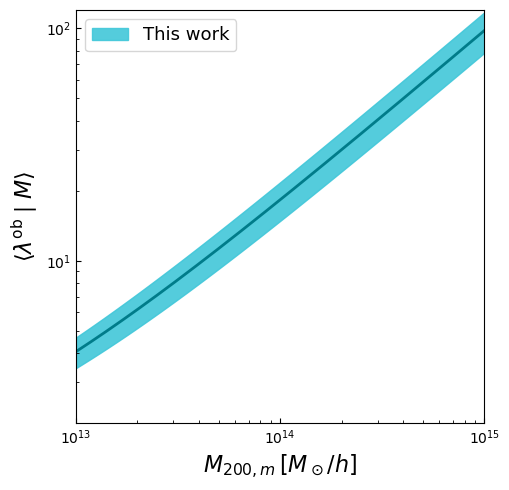

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------
# Parameters from your likelihood
# ------------------------------------------------
LOGM_MIN_FIXED = 11.13
LOGM1_FIXED    = 12.37
ALPHA_FIXED    = 0.748
ETA_FIXED      = -0.07
Z_PIVOT        = 0.45
SIGMA_INTR_FIXED = 0.2

Mmin = 10.0 ** LOGM_MIN_FIXED
M1   = 10.0 ** LOGM1_FIXED
alpha = ALPHA_FIXED
eta   = ETA_FIXED
sigma_intr = SIGMA_INTR_FIXED
z_pivot = Z_PIVOT

# ------------------------------------------------
# Richness model (same as likelihood logic)
# ------------------------------------------------
def mean_lambda_sat_y1(M, z, Mmin, M1, alpha, eta, z_pivot=0.45):
    M = np.asarray(M)
    mu = np.zeros_like(M)

    mask = M > Mmin
    mu[mask] = ((M[mask] - Mmin) / (M1 - Mmin)) ** alpha
    mu[mask] *= ((1 + z) / (1 + z_pivot)) ** eta

    return mu

def mean_lambda_total(M, z):
    lambda_cen = np.where(M >= Mmin, 1.0, 0.0)
    lambda_sat = mean_lambda_sat_y1(M, z, Mmin, M1, alpha, eta, z_pivot)
    return lambda_cen + lambda_sat

def sigma_lambda(M, z):
    lambda_sat = mean_lambda_sat_y1(M, z, Mmin, M1, alpha, eta, z_pivot)
    return sigma_intr * lambda_sat

# ------------------------------------------------
# Mass grid
# ------------------------------------------------
M = np.logspace(13, 15, 300)   # M200,m [Msun/h]
z = 0.45                       # same pivot redshift

lam_mean = mean_lambda_total(M, z)
lam_sigma = sigma_lambda(M, z)

lam_lo = np.clip(lam_mean - lam_sigma, 1e-3, None)
lam_hi = lam_mean + lam_sigma

# ------------------------------------------------
# Plot
# ------------------------------------------------
plt.figure(figsize=(5.2,5))

plt.fill_between(
    M,
    lam_lo,
    lam_hi,
    color="#41c7d9",
    alpha=0.9,
    label="This work"
)

plt.plot(M, lam_mean, color="#007c8a", lw=2)

plt.xscale("log")
plt.yscale("log")

plt.xlim(1e13, 1e15)
plt.ylim(2, 120)

plt.xlabel(r"$M_{200,m}\,[M_\odot/h]$", fontsize=16)
plt.ylabel(r"$\langle \lambda^{\rm ob} \mid M \rangle$", fontsize=16)

plt.legend(frameon=True, fontsize=13)
plt.tick_params(direction="in", which="both")

plt.tight_layout()
plt.show()